In [ ]:
from pathlib import Path
import importlib
import sys

import matplotlib
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == 'Task3' else cwd
if not (repo_root / 'Task3').exists():
    raise RuntimeError('Could not locate the repository root from the current working directory.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

full_analysis_module   = importlib.import_module('Task3.analysis.full_analysis')
parsing_module         = importlib.import_module('Task3.data.parsing')
summaries_module       = importlib.import_module('Task3.analysis.summaries')
collect_all_scores_module = importlib.import_module('Task3.pipelines.collect_all_scores')
rwfas_module           = importlib.import_module('Task3.scoring.rwfas')
merge_raw_metrics_module  = importlib.import_module('Task3.pipelines.merge_raw_metrics_across_seeds')
aggregate_rwfas_module    = importlib.import_module('Task3.pipelines.aggregate_rwfas_across_seeds')

full_analysis_module      = importlib.reload(full_analysis_module)
parsing_module            = importlib.reload(parsing_module)
summaries_module          = importlib.reload(summaries_module)
collect_all_scores_module = importlib.reload(collect_all_scores_module)
rwfas_module              = importlib.reload(rwfas_module)
merge_raw_metrics_module  = importlib.reload(merge_raw_metrics_module)
aggregate_rwfas_module    = importlib.reload(aggregate_rwfas_module)

run_full_perturbation_analysis = full_analysis_module.run_full_perturbation_analysis
load_batch_dataframe           = parsing_module.load_batch_dataframe
compute_baseline_deltas        = summaries_module.compute_baseline_deltas
collect_all_scores             = collect_all_scores_module.collect_all_scores
prepare_full_analysis_input    = collect_all_scores_module.prepare_full_analysis_input
RWFAS                          = rwfas_module.RWFAS
ensure_norm_columns            = rwfas_module.ensure_norm_columns
merge_raw_metrics_across_seeds = merge_raw_metrics_module.merge_raw_metrics_across_seeds
aggregate_rwfas_across_seeds   = aggregate_rwfas_module.aggregate_rwfas_across_seeds

METRICS       = ['fid', 'kid_mean', 'is_mean', 'precision', 'recall', 'density', 'coverage']
METRIC_LABELS = {'fid':'FID','kid_mean':'KID','is_mean':'IS','precision':'Precision',
                 'recall':'Recall','density':'Density','coverage':'Coverage'}

repo_root

WindowsPath('C:/Users/sofia/OneDrive/Desktop/Project_Master_2/Group07_Improving_Metrics')

In [ ]:
print('matplotlib backend:', matplotlib.get_backend())
print('collect_all_scores module:', collect_all_scores_module.__file__)
print('merge_raw_metrics module:',  merge_raw_metrics_module.__file__)
print('aggregate_rwfas module:',    aggregate_rwfas_module.__file__)
print('prepare_full_analysis_input id:', id(prepare_full_analysis_input))

matplotlib backend: module://matplotlib_inline.backend_inline
collect_all_scores module: C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Task3\pipelines\collect_all_scores.py
merge_raw_metrics module: C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Task3\pipelines\merge_raw_metrics_across_seeds.py
aggregate_rwfas module: C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Task3\pipelines\aggregate_rwfas_across_seeds.py
prepare_full_analysis_input id: 2550441235360


## Pipeline 1 : Per-seed RWFAS scores

Each seed report is processed independently: its own baseline is computed,
its own RWFAS weights are fitted, and one composite score is produced.
The output is one row per seed × model × dataset.

In [5]:

all_scores = collect_all_scores(
    outputs_root=repo_root / 'outputs' / 'batch_runs',
    save_csv=True,
    csv_path=repo_root / 'outputs' / 'task3_all_scores.csv',
    verbose=False,
)

             batch_label     model dataset  rwfas_score  rwfas_ci_low  rwfas_ci_high
     seed_01_dcgan_mnist     dcgan   mnist     0.492092      0.393609       0.590576
    seed_01_ddpm_cifar10      ddpm cifar10     0.468599      0.307688       0.629509
seed_01_stylegan2_celeba stylegan2  celeba     0.371604      0.293633       0.449574
     seed_02_dcgan_mnist     dcgan   mnist     0.467231      0.359996       0.574466
    seed_02_ddpm_cifar10      ddpm cifar10     0.444963      0.284762       0.605164
seed_02_stylegan2_celeba stylegan2  celeba     0.368914      0.324704       0.413123
     seed_03_dcgan_mnist     dcgan   mnist     0.450014      0.347299       0.552728
    seed_03_ddpm_cifar10      ddpm cifar10     0.468606      0.307297       0.629915
seed_03_stylegan2_celeba stylegan2  celeba     0.362974      0.322941       0.403007
     seed_04_dcgan_mnist     dcgan   mnist     0.468950      0.366854       0.571046
    seed_04_ddpm_cifar10      ddpm cifar10     0.461068      0.30

### Per-seed scores : overview
One row per seed. Check score range and whether CIs are meaningful (non-zero width).

In [6]:
display(all_scores[['batch_label','model','dataset','rwfas_score','rwfas_ci_low','rwfas_ci_high']].to_string(index=False))


missing_ci = all_scores[all_scores['rwfas_ci_low'].isna() & all_scores['rwfas_ci_high'].isna()]
if not missing_ci.empty:
    print(f'\nWARNING: {len(missing_ci)} row(s) have no propagated CI (bootstrap CI columns missing):')
    print(missing_ci[['batch_label','model','dataset']].to_string(index=False))
else:
    print('\nAll rows have a propagated CI')

'             batch_label     model dataset  rwfas_score  rwfas_ci_low  rwfas_ci_high\n     seed_01_dcgan_mnist     dcgan   mnist     0.492092      0.393609       0.590576\n    seed_01_ddpm_cifar10      ddpm cifar10     0.468599      0.307688       0.629509\nseed_01_stylegan2_celeba stylegan2  celeba     0.371604      0.293633       0.449574\n     seed_02_dcgan_mnist     dcgan   mnist     0.467231      0.359996       0.574466\n    seed_02_ddpm_cifar10      ddpm cifar10     0.444963      0.284762       0.605164\nseed_02_stylegan2_celeba stylegan2  celeba     0.368914      0.324704       0.413123\n     seed_03_dcgan_mnist     dcgan   mnist     0.450014      0.347299       0.552728\n    seed_03_ddpm_cifar10      ddpm cifar10     0.468606      0.307297       0.629915\nseed_03_stylegan2_celeba stylegan2  celeba     0.362974      0.322941       0.403007\n     seed_04_dcgan_mnist     dcgan   mnist     0.468950      0.366854       0.571046\n    seed_04_ddpm_cifar10      ddpm cifar10     0.4610


All rows have a propagated CI


### Per-seed weight breakdown

Each seed produces its own set of weights because trustworthiness is estimated
from that seed's perturbation responses. So we check whether weights are consistent
across seeds: large variation suggests the metric rankings are unstable.

Weight mean ± std across seeds (per model/dataset):


weight_fid_mean  weight_fid_std  weight_kid_mean_mean  \
model     dataset                                                          
dcgan     cifar10              0.0             NaN                0.0000   
          mnist                0.0             0.0                0.0961   
ddpm      cifar10              0.0             0.0                0.0000   
stylegan2 celeba               0.0             0.0                0.6611   

                   weight_kid_mean_std  weight_is_mean_mean  \
model     dataset                                             
dcgan     cifar10                  NaN               0.0000   
          mnist                 0.0113               0.0000   
ddpm      cifar10               0.0000               0.0013   
stylegan2 celeba                0.1210               0.0000   

                   weight_is_mean_std  weight_precision_mean  \
model     dataset                                              
dcgan     cifar10                 NaN                 0.3618   
          mnist                0.0000                 0.4651   
ddpm      cifar10              0.0012                 0.4834   
stylegan2 celeba               0.0000                 0.0477   

                   weight_precision_std  weight_recall_mean  \
model     dataset                                             
dcgan     cifar10                   NaN              0.0007   
          mnist                  0.0337              0.0013   
ddpm      cifar10                0.0174              0.0029   
stylegan2 celeba                 0.0953              0.0000   

                   weight_recall_std  weight_density_mean  weight_density_std  \
model     dataset                                                               
dcgan     cifar10                NaN               0.6335                 NaN   
          mnist               0.0009               0.4375              0.0344   
ddpm      cifar10             0.0044               0.5107              0.0157   
stylegan2 celeba              0.0000               0.2913              0.0304   

                   weight_coverage_mean  weight_coverage_std  
model     dataset                                             
dcgan     cifar10                0.0040                  NaN  
          mnist                  0.0000               0.0000  
ddpm      cifar10                0.0017               0.0016  
stylegan2 celeba                 0.0000               0.0000

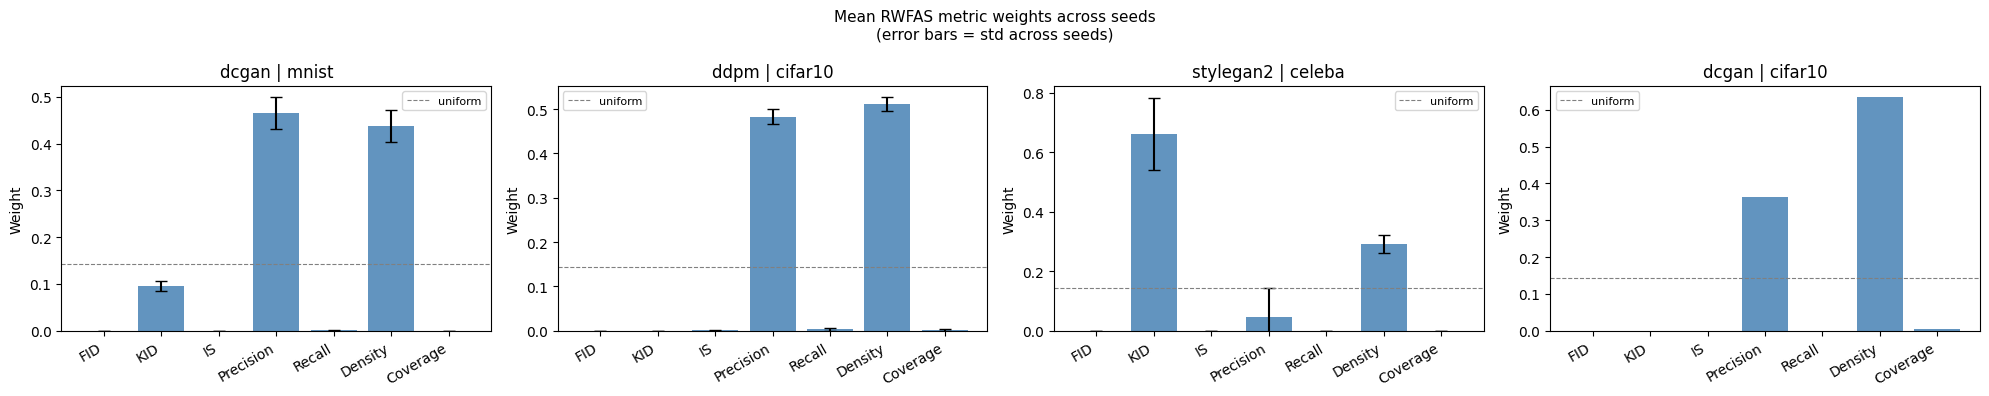

In [7]:
weight_cols = [c for c in all_scores.columns if c.startswith('weight_')]
if weight_cols and len(all_scores) > 0:
    weight_summary = all_scores.groupby(['model','dataset'])[weight_cols].agg(['mean','std'])
    weight_summary.columns = ['_'.join(c) for c in weight_summary.columns]
    print('Weight mean ± std across seeds (per model/dataset):')
    display(weight_summary.round(4))

    # Bar chart: mean weights with std error bars, one group per model/dataset
    pairs = all_scores[['model','dataset']].drop_duplicates().values.tolist()
    n_pairs = len(pairs)
    fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4), squeeze=False)
    metric_short = [METRIC_LABELS.get(c.replace('weight_',''), c.replace('weight_','')) for c in weight_cols]

    for ax, (model, dataset) in zip(axes[0], pairs):
        sub = all_scores[(all_scores['model']==model) & (all_scores['dataset']==dataset)]
        means = sub[weight_cols].mean().to_numpy(dtype=float)
        stds  = sub[weight_cols].std().to_numpy(dtype=float)
        x = np.arange(len(weight_cols))
        ax.bar(x, means, yerr=stds, capsize=4, color='steelblue', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_short, rotation=30, ha='right')
        ax.set_ylabel('Weight')
        ax.set_title(f'{model} | {dataset}')
        ax.set_ylim(0, None)
        ax.axhline(1/len(weight_cols), linestyle='--', color='grey', linewidth=0.8, label='uniform')
        ax.legend(fontsize=8)

    fig.suptitle('Mean RWFAS metric weights across seeds\n(error bars = std across seeds)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('No weight columns found in all_scores.')

### Per-seed goodness component scores

Each score_{metric} column is the per-metric goodness score: 0.5 = no change
from baseline, >0.5 = model degrades less than baseline, <0.5 = degrades more.
This shows which metric axes are driving the composite score.

In [8]:
score_cols = [f'score_{m}' for m in METRICS if f'score_{m}' in all_scores.columns]
if score_cols:
    pairs = all_scores[['model','dataset']].drop_duplicates().values.tolist()
    for model, dataset in pairs:
        sub = all_scores[(all_scores['model']==model) & (all_scores['dataset']==dataset)]
        print(f'\n{model} | {dataset}  (n_seeds={len(sub)})')
        comp_summary = sub[score_cols].agg(['mean','std','min','max']).T
        comp_summary.index = [METRIC_LABELS.get(c.replace('score_',''), c) for c in comp_summary.index]
        comp_summary.columns = ['mean','std','min','max']
        display(comp_summary.round(4))
        below = comp_summary[comp_summary['mean'] < 0.45]
        above = comp_summary[comp_summary['mean'] > 0.55]
        if not below.empty:
            print(f'  Axes clearly below baseline (mean < 0.45): {list(below.index)}')
        if not above.empty:
            print(f'  Axes clearly above baseline (mean > 0.55): {list(above.index)}')
        if below.empty and above.empty:
            print('  All axes close to baseline (0.45 – 0.55).')


dcgan | mnist  (n_seeds=5)


,mean,std,min,max
FID,0.4214,0.0060,0.4149,0.4283
KID,0.4361,0.0048,0.4292,0.4428
IS,0.4840,0.0053,0.4757,0.4890
Precision,0.4733,0.0171,0.4507,0.4924
Recall,0.4494,0.0166,0.4334,0.4755
Density,0.4787,0.0198,0.4522,0.5057
Coverage,0.4543,0.0174,0.4357,0.4810


  Axes clearly below baseline (mean < 0.45): ['FID', 'KID', 'Recall']

ddpm | cifar10  (n_seeds=5)


,mean,std,min,max
FID,0.3849,0.0073,0.3775,0.3939
KID,0.3650,0.0372,0.3103,0.4062
IS,0.4429,0.0058,0.4372,0.4490
Precision,0.4737,0.0043,0.4674,0.4779
Recall,0.4327,0.0105,0.4179,0.4447
Density,0.4539,0.0179,0.4228,0.4677
Coverage,0.4340,0.0083,0.4244,0.4453


  Axes clearly below baseline (mean < 0.45): ['FID', 'KID', 'IS', 'Recall', 'Coverage']

stylegan2 | celeba  (n_seeds=4)


,mean,std,min,max
FID,0.3078,0.0116,0.2940,0.3184
KID,0.3263,0.0076,0.3151,0.3314
IS,0.4593,0.0027,0.4559,0.4616
Precision,0.3938,0.0005,0.3934,0.3944
Recall,0.4548,0.0236,0.4321,0.4873
Density,0.4477,0.0064,0.4420,0.4567
Coverage,0.4637,0.0127,0.4456,0.4742


  Axes clearly below baseline (mean < 0.45): ['FID', 'KID', 'Precision', 'Density']

dcgan | cifar10  (n_seeds=1)


,mean,std,min,max
FID,0.4100,NaN,0.4100,0.4100
KID,0.4075,NaN,0.4075,0.4075
IS,0.4594,NaN,0.4594,0.4594
Precision,0.4844,NaN,0.4844,0.4844
Recall,0.4342,NaN,0.4342,0.4342
Density,0.4742,NaN,0.4742,0.4742
Coverage,0.4623,NaN,0.4623,0.4623


  Axes clearly below baseline (mean < 0.45): ['FID', 'KID', 'Recall']


---
## Pipeline 2 : Raw metric aggregation across seeds

Raw metric values are pooled across seeds for each experimental condition
(model × dataset × perturbation × severity). This gives seed-averaged metric
estimates with explicit cross-seed uncertainty, independently of the RWFAS scoring.

In [9]:
# Merge raw experiment metrics across repeated seeds.
raw_metrics_merged = merge_raw_metrics_across_seeds(
    outputs_root=repo_root / 'outputs',
    save_csv=True,
    csv_path=repo_root / 'outputs' / 'task3_raw_metrics_across_seeds.csv',
    verbose=False,
)

,model,dataset,name,seed_count,fid_mean,kid_mean_mean,is_mean_mean
0,dcgan,cifar10,baseline_no_perturbation,1,53.921529,0.021737,4.794642
1,dcgan,cifar10,class_imbalance_label_0_05pct,1,52.994040,0.020959,5.000390
2,dcgan,cifar10,class_imbalance_label_0_15pct,1,53.557798,0.021598,4.710555
3,dcgan,cifar10,class_imbalance_label_0_1_2_8_9_05pct,1,52.321454,0.020386,4.769933
4,dcgan,cifar10,class_imbalance_label_0_1_2_8_9_15pct,1,53.204371,0.021856,4.783392
5,dcgan,cifar10,class_imbalance_label_0_1_2_8_9_30pct,1,53.937456,0.022067,4.795310
6,dcgan,cifar10,class_imbalance_label_0_1_2_8_9_50pct,1,56.328923,0.023986,4.750303
7,dcgan,cifar10,class_imbalance_label_0_1_2_8_9_75pct,1,58.428344,0.026433,4.654240
8,dcgan,cifar10,class_imbalance_label_0_1_2_8_9_90pct,1,60.086501,0.027860,4.579485
9,dcgan,cifar10,class_imbalance_label_0_2_8_05pct,1,54.031911,0.021697,4.744052


In [10]:
# Quick check of merged baseline rows
raw_metrics_merged.loc[
    raw_metrics_merged['name'].astype(str).str.contains('baseline', case=False, na=False),
    ['model', 'dataset', 'name', 'seed_count', 'fid_mean', 'fid_ci_low', 'fid_ci_high', 'precision_mean', 'coverage_mean'],
]

,model,dataset,name,seed_count,fid_mean,fid_ci_low,fid_ci_high,precision_mean,coverage_mean
0,dcgan,cifar10,baseline_no_perturbation,1,53.921529,NaN,NaN,0.714063,0.477344
213,dcgan,mnist,baseline_no_perturbation,5,31.829770,31.163040,32.496500,0.392969,0.375000
426,ddpm,cifar10,baseline_no_perturbation,5,27.616546,26.683902,28.549190,0.811406,0.907969
639,stylegan2,celeba,baseline_no_perturbation,4,65.351392,64.814599,65.888184,0.523633,0.293164


### Seed coverage check

How many seeds contributed to each experimental condition?
Conditions with fewer seeds have wider cross-seed uncertainty.

In [11]:
if not raw_metrics_merged.empty:
    seed_counts = raw_metrics_merged.groupby(['model','dataset'])['seed_count'].agg(['min','max','mean']).round(2)
    print('Seed count per (model, dataset):')
    display(seed_counts)

    single_seed = raw_metrics_merged[raw_metrics_merged['seed_count'] <= 1]
    if not single_seed.empty:
        print(f'\nWARNING: {len(single_seed)} experimental conditions have only 1 seed.')
        print('Cross-seed CI will be NaN for these rows.')
    else:
        print('\nAll conditions have >= 2 seeds. Cross-seed CIs are available.')

Seed count per (model, dataset):


min  max  mean
model     dataset                
dcgan     cifar10    1    1  1.00
          mnist      5    5  5.00
ddpm      cifar10    5    5  5.00
stylegan2 celeba     1    4  3.78


Cross-seed CI will be NaN for these rows.


### Cross-seed variance per metric

Which metrics are most stable across seeds at baseline?
High variance at baseline suggests the metric estimator is sensitive
to the random seed of the generative model itself.

In [12]:
if not raw_metrics_merged.empty:
    baseline_rows = raw_metrics_merged[
        raw_metrics_merged['name'].astype(str).str.contains('baseline', case=False, na=False)
    ]
    if baseline_rows.empty:
        print('No baseline rows found in merged raw metrics.')
    else:
        std_cols = [f'{m}_std' for m in METRICS if f'{m}_std' in baseline_rows.columns]
        mean_cols = [f'{m}_mean' for m in METRICS if f'{m}_mean' in baseline_rows.columns]

        pairs = baseline_rows[['model','dataset']].drop_duplicates().values.tolist()
        for model, dataset in pairs:
            sub = baseline_rows[(baseline_rows['model']==model) & (baseline_rows['dataset']==dataset)]
            print(f'\nBaseline cross-seed std : {model} | {dataset}:')
            row = {}
            for m in METRICS:
                mc = f'{m}_mean'
                sc = f'{m}_std'
                if mc in sub.columns and sc in sub.columns:
                    mn = sub[mc].mean()
                    sd = sub[sc].mean()
                    cv = abs(sd / mn) if mn and mn != 0 else float('nan')
                    row[METRIC_LABELS[m]] = {'mean': round(mn,4), 'std': round(sd,4), 'CV': round(cv,4)}
            display(pd.DataFrame(row).T)


Baseline cross-seed std : dcgan | cifar10:


,mean,std,CV
FID,53.9215,NaN,NaN
KID,0.0217,NaN,NaN
IS,4.7946,NaN,NaN
Precision,0.7141,NaN,NaN
Recall,0.4734,NaN,NaN
Density,0.6311,NaN,NaN
Coverage,0.4773,NaN,NaN



Baseline cross-seed std : dcgan | mnist:


,mean,std,CV
FID,31.8298,0.5370,0.0169
KID,0.0251,0.0004,0.0170
IS,2.3855,0.0271,0.0114
Precision,0.3930,0.0268,0.0682
Recall,0.5509,0.0193,0.0350
Density,0.1619,0.0151,0.0935
Coverage,0.3750,0.0225,0.0600



Baseline cross-seed std : ddpm | cifar10:


,mean,std,CV
FID,27.6165,0.7511,0.0272
KID,0.0057,0.0006,0.1051
IS,7.0433,0.1168,0.0166
Precision,0.8114,0.0144,0.0177
Recall,0.7106,0.0186,0.0262
Density,1.0200,0.0604,0.0592
Coverage,0.9080,0.0240,0.0264



Baseline cross-seed std : stylegan2 | celeba:


,mean,std,CV
FID,65.3514,0.3373,0.0052
KID,0.0556,0.0007,0.0123
IS,2.5676,0.0290,0.0113
Precision,0.5236,0.0038,0.0072
Recall,0.0795,0.0167,0.2105
Density,0.2357,0.0063,0.0268
Coverage,0.2932,0.0078,0.0268


### Raw metric response curves (seed-averaged)

Visualise how a chosen metric evolves across perturbation conditions for one
model/dataset. Change `metric`, `model_id`, `dataset_id` as needed.

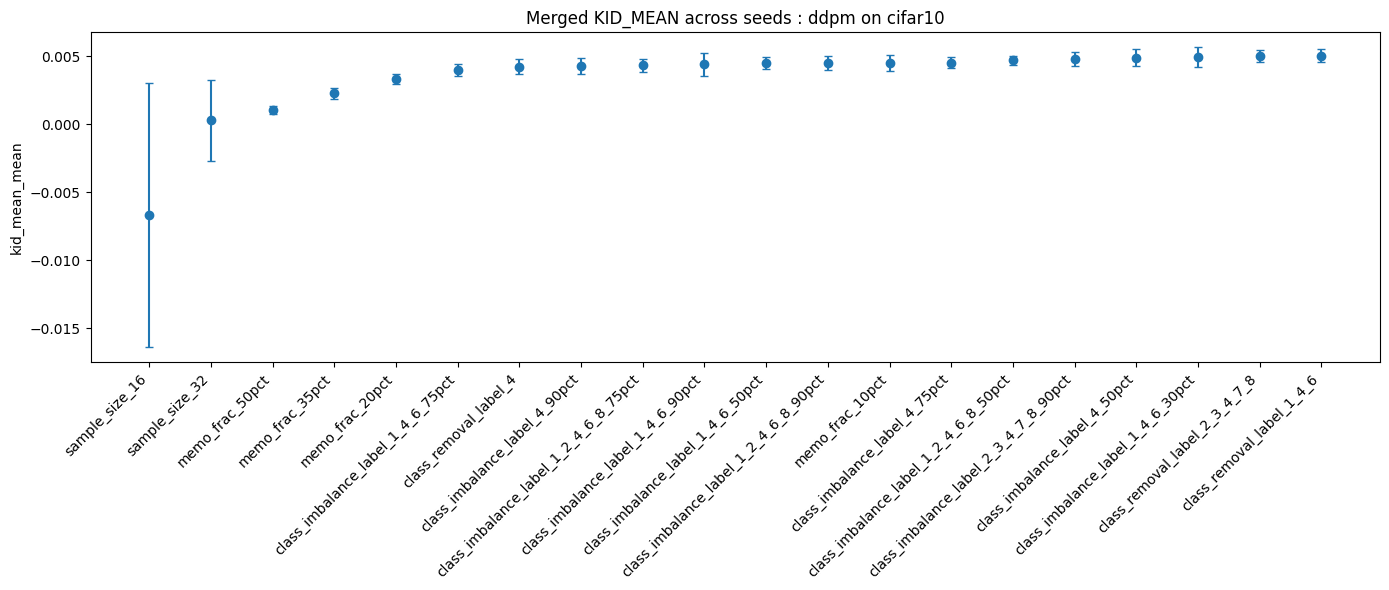

In [13]:
metric     = 'kid_mean'
model_id   = 'ddpm'
dataset_id = 'cifar10'

plot_df = raw_metrics_merged[
    (raw_metrics_merged['model'] == model_id)
    & (raw_metrics_merged['dataset'] == dataset_id)
].copy()

plot_df = plot_df[['name', f'{metric}_mean', f'{metric}_ci_low', f'{metric}_ci_high']].dropna(subset=[f'{metric}_mean'])
plot_df = plot_df.sort_values(f'{metric}_mean').head(20)

x = np.arange(len(plot_df))
y    = plot_df[f'{metric}_mean'].to_numpy(dtype=float)
low  = plot_df[f'{metric}_ci_low'].to_numpy(dtype=float)
high = plot_df[f'{metric}_ci_high'].to_numpy(dtype=float)
err_low  = np.where(np.isfinite(low),  np.maximum(0.0, y - low),  np.nan)
err_high = np.where(np.isfinite(high), np.maximum(0.0, high - y), np.nan)

plt.figure(figsize=(14, 6))
plt.errorbar(x, y, yerr=np.vstack([err_low, err_high]), fmt='o', capsize=3)
plt.xticks(x, plot_df['name'], rotation=45, ha='right')
plt.title(f'Merged {metric.upper()} across seeds : {model_id} on {dataset_id}')
plt.ylabel(f'{metric}_mean')
plt.tight_layout()
plt.show()

---
## Pipeline 3 : RWFAS aggregated across seeds

The per-seed RWFAS scores from Pipeline 1 are pooled by (model, dataset).
This is the primary result: a stable composite score with a cross-seed
confidence interval that reflects how consistently the model is assessed.

In [14]:

rwfas_across_seeds = aggregate_rwfas_across_seeds(
    outputs_root=repo_root / 'outputs' / 'batch_runs',
    save_csv=True,
    csv_path=repo_root / 'outputs' / 'task3_rwfas_across_seeds.csv',
    verbose=False,
)

rwfas_across_seeds

             batch_label     model dataset  rwfas_score  rwfas_ci_low  rwfas_ci_high
     seed_01_dcgan_mnist     dcgan   mnist     0.492092      0.393609       0.590576
    seed_01_ddpm_cifar10      ddpm cifar10     0.468599      0.307688       0.629509
seed_01_stylegan2_celeba stylegan2  celeba     0.371604      0.293633       0.449574
     seed_02_dcgan_mnist     dcgan   mnist     0.467231      0.359996       0.574466
    seed_02_ddpm_cifar10      ddpm cifar10     0.444963      0.284762       0.605164
seed_02_stylegan2_celeba stylegan2  celeba     0.368914      0.324704       0.413123
     seed_03_dcgan_mnist     dcgan   mnist     0.450014      0.347299       0.552728
    seed_03_ddpm_cifar10      ddpm cifar10     0.468606      0.307297       0.629915
seed_03_stylegan2_celeba stylegan2  celeba     0.362974      0.322941       0.403007
     seed_04_dcgan_mnist     dcgan   mnist     0.468950      0.366854       0.571046
    seed_04_ddpm_cifar10      ddpm cifar10     0.461068      0.30

,model,dataset,seed_count,rwfas_score_mean,rwfas_score_ci_low,rwfas_score_ci_high,rwfas_reported_ci_half_mean
0,dcgan,cifar10,1,0.477808,NaN,NaN,0.174180
1,dcgan,mnist,5,0.471988,0.452235,0.491742,0.101354
2,ddpm,cifar10,5,0.463192,0.449503,0.476881,0.160607
3,stylegan2,celeba,4,0.365502,0.356129,0.374874,0.050540


,model,dataset,row_count,seed_count,batch_count,seed_labels,batch_labels,rwfas_score_n,rwfas_score_mean,rwfas_score_std,...,comp_reliability_coverage_n,comp_reliability_coverage_mean,comp_reliability_coverage_std,comp_reliability_coverage_sem,comp_reliability_coverage_ci_low,comp_reliability_coverage_ci_high,comp_reliability_coverage_min,comp_reliability_coverage_max,rwfas_reported_ci_half_mean,rwfas_reported_ci_half_std
0,dcgan,cifar10,1,1,1,seed_05,seed_05_dcgan_cifar10,1,0.477808,NaN,...,1,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.174180,NaN
1,dcgan,mnist,5,5,5,"seed_01,seed_02,seed_03,seed_04,seed_05","seed_01_dcgan_mnist,seed_02_dcgan_mnist,seed_0...",5,0.471988,0.015909,...,5,0.998844,0.001146,0.000513,0.997421,1.000267,0.997129,1.000000,0.101354,0.004224
2,ddpm,cifar10,5,5,5,"seed_01,seed_02,seed_03,seed_04,seed_05","seed_01_ddpm_cifar10,seed_02_ddpm_cifar10,seed...",5,0.463192,0.011025,...,5,0.998075,0.000953,0.000426,0.996891,0.999258,0.996932,0.999239,0.160607,0.003266
3,stylegan2,celeba,4,4,4,"seed_01,seed_02,seed_03,seed_04","seed_01_stylegan2_celeba,seed_02_stylegan2_cel...",4,0.365502,0.005890,...,4,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.050540,0.018395


### Comparing the two sources of uncertainty

rwfas_reported_ci_half_mean is the mean within-seed CI half-width
(propagated from bootstrap CIs, uncertainty due to finite sample size).
rwfas_score_ci_low/high is the cross-seed CI
(uncertainty due to the random seed of the generative model).
If the cross-seed CI is much wider, the model's random seed matters more
than sample size for the reliability of the assessment.

In [15]:
if not rwfas_across_seeds.empty:
    cmp_cols = ['model','dataset','seed_count',
                'rwfas_score_mean','rwfas_score_std',
                'rwfas_reported_ci_half_mean']
    cmp_cols = [c for c in cmp_cols if c in rwfas_across_seeds.columns]
    display(rwfas_across_seeds[cmp_cols].round(4))

    # for each model/dataset, compare the two half-widths
    for _, row in rwfas_across_seeds.iterrows():
        within_half = row.get('rwfas_reported_ci_half_mean', float('nan'))
        across_std  = row.get('rwfas_score_std', float('nan'))
        across_half = across_std / np.sqrt(max(row.get('seed_count', 1), 1))
        label = f"{row.get('model','?')} | {row.get('dataset','?')}"
        print(f'{label}:')
        print(f'  Within-seed CI half-width (bootstrap): {within_half:.4f}')
        print(f'  Across-seed CI half-width (t-interval): {across_half:.4f}')
        if np.isfinite(within_half) and np.isfinite(across_half) and within_half > 0:
            ratio = across_half / within_half
            dominant = 'seed randomness' if ratio > 1.5 else ('sample size' if ratio < 0.67 else 'comparable')
            print(f'  Ratio across/within: {ratio:.2f}  -> dominant source: {dominant}')
        print()

,model,dataset,seed_count,rwfas_score_mean,rwfas_score_std,rwfas_reported_ci_half_mean
0,dcgan,cifar10,1,0.4778,NaN,0.1742
1,dcgan,mnist,5,0.4720,0.0159,0.1014
2,ddpm,cifar10,5,0.4632,0.0110,0.1606
3,stylegan2,celeba,4,0.3655,0.0059,0.0505


dcgan | cifar10:
  Within-seed CI half-width (bootstrap): 0.1742
  Across-seed CI half-width (t-interval): nan

dcgan | mnist:
  Within-seed CI half-width (bootstrap): 0.1014
  Across-seed CI half-width (t-interval): 0.0071
  Ratio across/within: 0.07  -> dominant source: sample size

ddpm | cifar10:
  Within-seed CI half-width (bootstrap): 0.1606
  Across-seed CI half-width (t-interval): 0.0049
  Ratio across/within: 0.03  -> dominant source: sample size

stylegan2 | celeba:
  Within-seed CI half-width (bootstrap): 0.0505
  Across-seed CI half-width (t-interval): 0.0029
  Ratio across/within: 0.06  -> dominant source: sample size



### RWFAS scores : bar chart with cross-seed CI

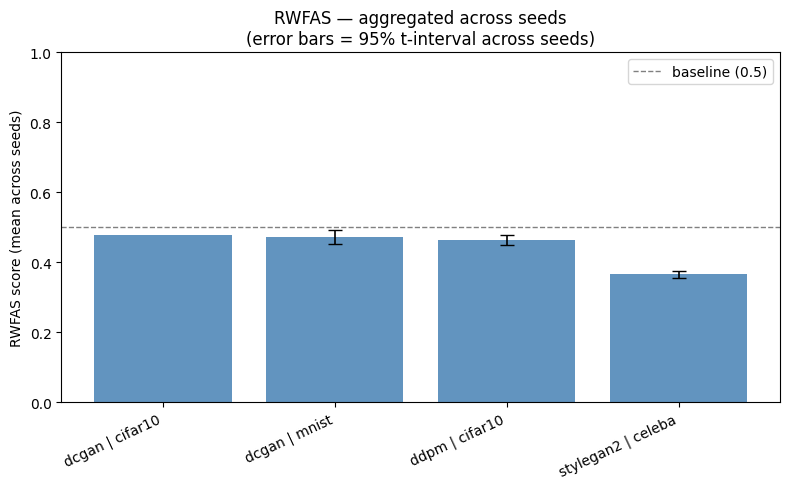

In [16]:
if not rwfas_across_seeds.empty:
    labels   = rwfas_across_seeds['model'].astype(str) + ' | ' + rwfas_across_seeds['dataset'].astype(str)
    x    = np.arange(len(rwfas_across_seeds))
    y    = rwfas_across_seeds['rwfas_score_mean'].to_numpy(dtype=float)
    low  = rwfas_across_seeds['rwfas_score_ci_low'].to_numpy(dtype=float)
    high = rwfas_across_seeds['rwfas_score_ci_high'].to_numpy(dtype=float)
    err_low  = np.where(np.isfinite(low),  np.maximum(0.0, y - low),  np.nan)
    err_high = np.where(np.isfinite(high), np.maximum(0.0, high - y), np.nan)

    plt.figure(figsize=(max(8, len(rwfas_across_seeds) * 2), 5))
    plt.bar(x, y, color='steelblue', alpha=0.85)
    plt.errorbar(x, y, yerr=np.vstack([err_low, err_high]),
                 fmt='none', ecolor='black', capsize=5, linewidth=1.2)
    plt.axhline(0.5, linestyle='--', color='grey', linewidth=1.0, label='baseline (0.5)')
    plt.xticks(x, labels, rotation=25, ha='right')
    plt.ylabel('RWFAS score (mean across seeds)')
    plt.ylim(0, 1)
    plt.title('RWFAS — aggregated across seeds\n(error bars = 95% t-interval across seeds)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(repo_root / 'outputs' / 'task3_rwfas_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No aggregated RWFAS rows were produced.')

### Failure mode fingerprint : radar chart

Each axis is one metric's goodness score (0.5 = baseline, >0.5 = better,
<0.5 = worse). The dashed circle marks the baseline. The shape of the polygon
reveals *which* failure modes dominate: a model collapsed on the left
(fidelity axes) suffers from image quality degradation; one collapsed on the
right (coverage axes) suffers from mode dropping.

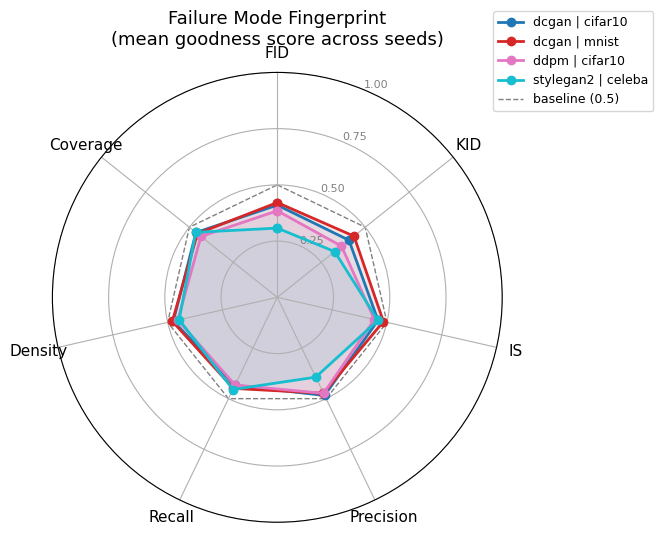

Saved: outputs/task3_fingerprint_radar.png


In [17]:

score_cols = [f'score_{m}' for m in METRICS]

# collect mean score per (model, dataset) from all_scores
if not all_scores.empty and all(c in all_scores.columns for c in score_cols):
    fingerprint_df = (
        all_scores
        .groupby(['model','dataset'], dropna=False)[score_cols]
        .mean()
        .reset_index()
    )

    N = len(METRICS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close the polygon

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    colors = plt.cm.tab10(np.linspace(0, 1, len(fingerprint_df)))

    for (_, row), color in zip(fingerprint_df.iterrows(), colors):
        values = [row[f'score_{m}'] for m in METRICS]
        values = [v if np.isfinite(v) else 0.5 for v in values]
        values += values[:1]
        label = f"{row['model']} | {row['dataset']}"
        ax.plot(angles, values, 'o-', linewidth=2, label=label, color=color)
        ax.fill(angles, values, alpha=0.10, color=color)

    # Baseline circle at 0.5
    baseline_vals = [0.5] * N + [0.5]
    ax.plot(angles, baseline_vals, '--', color='grey', linewidth=1.0,
            label='baseline (0.5)', zorder=0)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=8, color='grey')
    ax.set_title('Failure Mode Fingerprint\n(mean goodness score across seeds)',
                 fontsize=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

    plt.tight_layout()
    plt.savefig(repo_root / 'outputs' / 'task3_fingerprint_radar.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/task3_fingerprint_radar.png')
else:
    print('score_ columns not found in all_scores. Run Pipeline 1 first.')

### Fingerprint interpretation guide

| Score range | Meaning |
|---|---|
| > 0.55 | Model degrades **less** than baseline on this axis — robust |
| 0.45 – 0.55 | Indistinguishable from baseline |
| < 0.45 | Model degrades **more** than baseline on this axis — failure mode |

**Fidelity axes** (FID, KID, Precision, Density): driven by degradation
and memoisation perturbations. A collapsed fidelity axis means generated
images lose quality under these conditions faster than expected.

**Coverage axes** (Recall, Coverage, IS): driven by class removal and
class imbalance perturbations. A collapsed coverage axis means the model
loses diversity or mode coverage faster than expected.

A model with all axes near 0.5 performs comparably to baseline across all
perturbation types — neither particularly robust nor particularly fragile.

---
## Single-batch deep dive

The cells below re-run the full pipeline on one report file so you can
inspect the raw component tables (sensitivity, specificity, monotonicity)
that feed into the weights. Useful for debugging or reporting per-metric
details for a specific model/seed.

In [ ]:

report_candidates = sorted((repo_root / 'outputs').glob('*perturbation_tests*.json'))
if not report_candidates:
    raise RuntimeError('No perturbation batch reports were found in outputs/.')

report_path = report_candidates[1]
print('Using report:', report_path.name)

Using report: seed_01_ddpm_cifar10_perturbation_tests.json


In [20]:
df = load_batch_dataframe([report_path])
df_delta, _ = compute_baseline_deltas(df)
df_delta = ensure_norm_columns(df_delta)

df_delta.loc[
    df_delta['name'].astype(str).str.contains('baseline', case=False, na=False),
    ['name', 'model', 'dataset', 'fid', 'fid_baseline', 'fid_delta', 'fid_norm'],
]

Rows loaded: 213
Columns: 51


,fid_delta,kid_mean_delta,is_mean_delta,precision_delta,recall_delta,density_delta,coverage_delta
perturbation_family,,,,,,,
baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
class_imbalance,0.278167,0.000284,-0.169482,0.007801,-0.011624,0.035141,0.017264
class_removal,1.560383,0.001314,-0.220674,0.008381,-0.019567,0.040781,0.004865
degradation_all,223.816016,0.313050,-5.011535,-0.319688,-0.659375,-0.592469,-0.725313
degradation_blur,183.414047,0.200678,-4.769263,-0.420938,-0.634687,-0.693125,-0.713125
degradation_jpeg,83.440445,0.116973,-2.870256,-0.171875,-0.389844,-0.384563,-0.454688
degradation_noise,179.635356,0.202954,-4.153312,-0.375469,-0.582500,-0.754469,-0.697969
domain_shift,248.644819,0.241602,0.000000,-0.800000,-0.503125,-0.970938,-0.877344
memoisation,-6.213184,-0.002001,0.320587,0.036942,0.066406,0.010022,0.053348


,name,model,dataset,fid,fid_baseline,fid_delta,fid_norm
0,baseline_no_perturbation,ddpm,cifar10,28.342562,28.342562,0.0,0.0


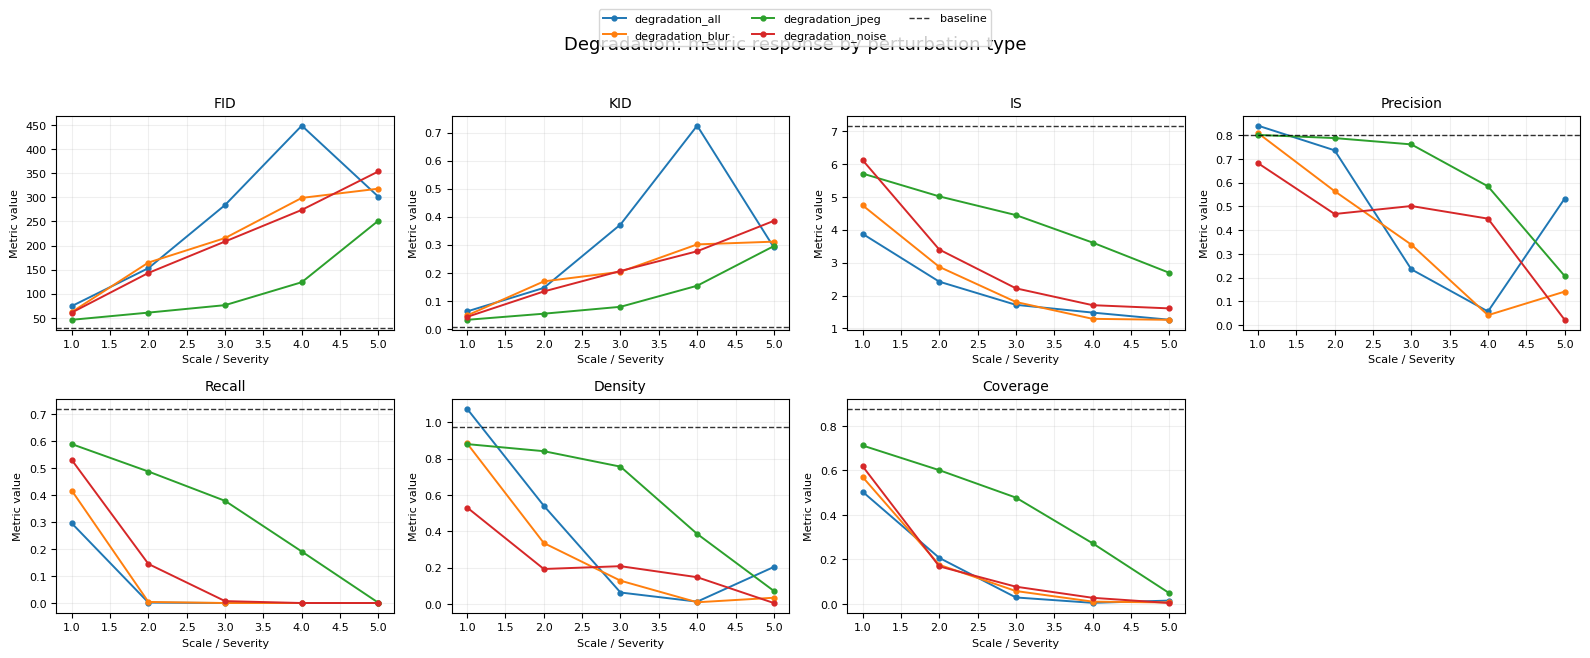

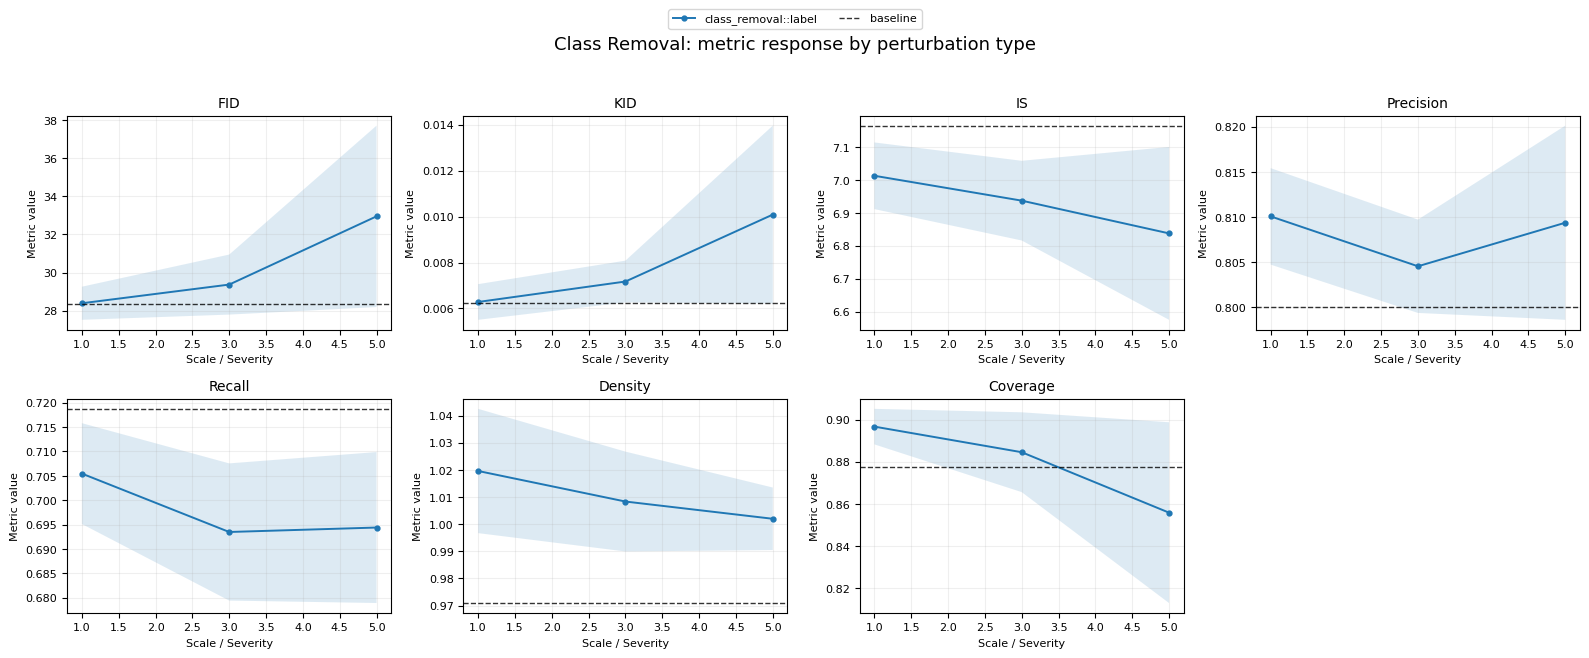

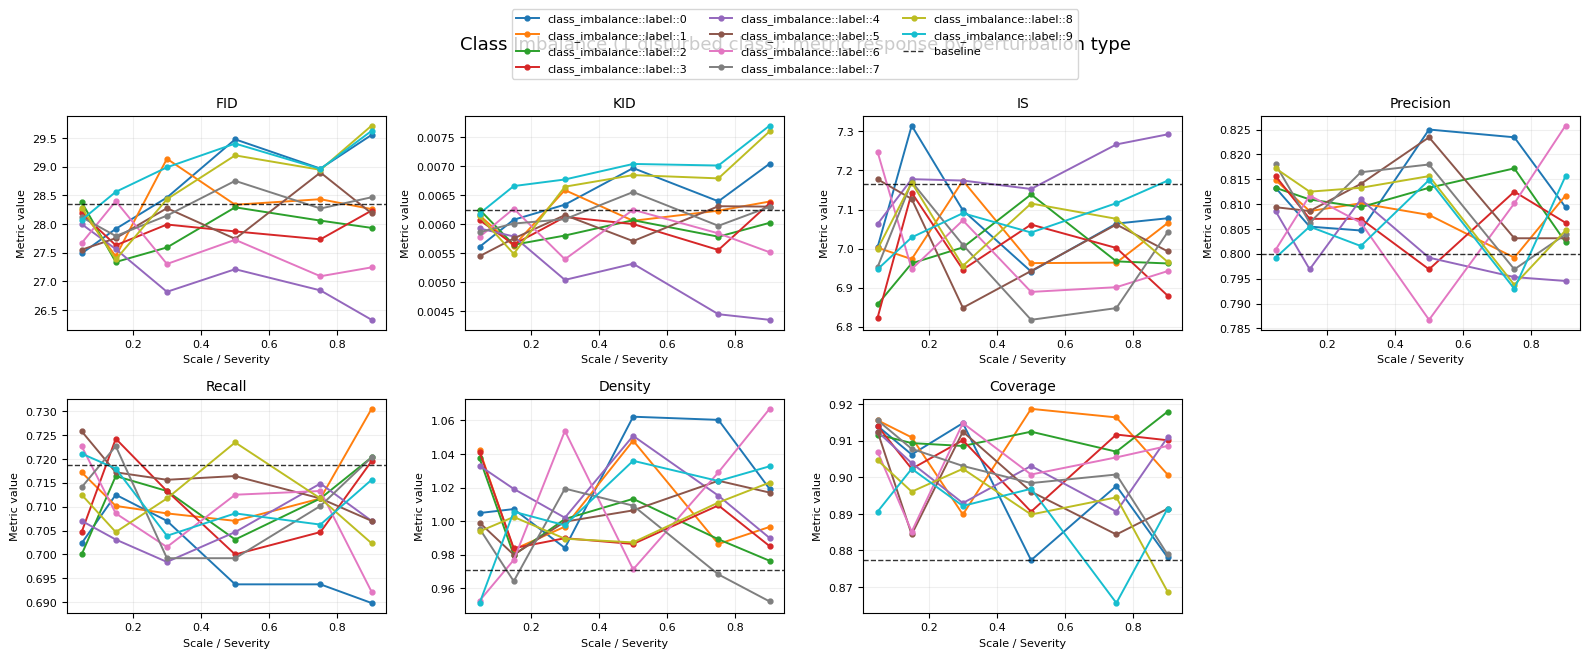

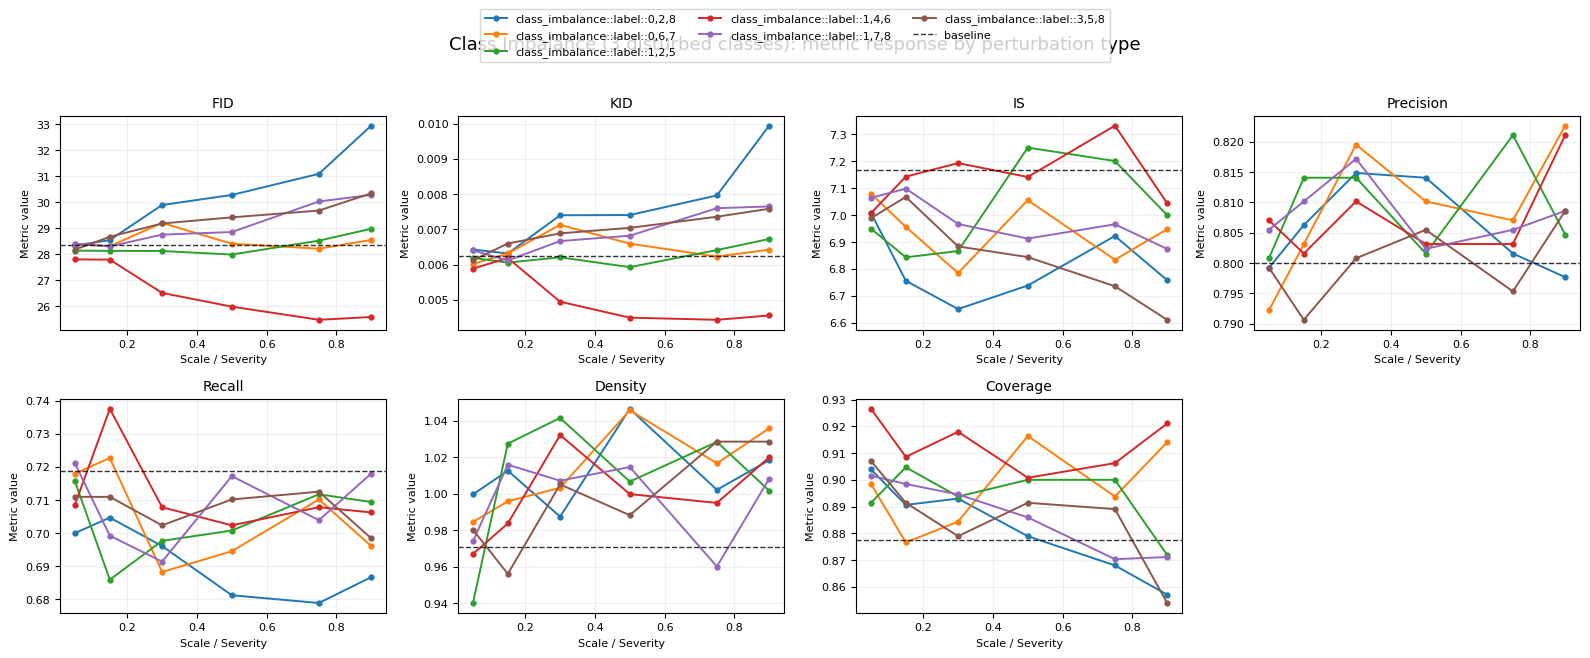

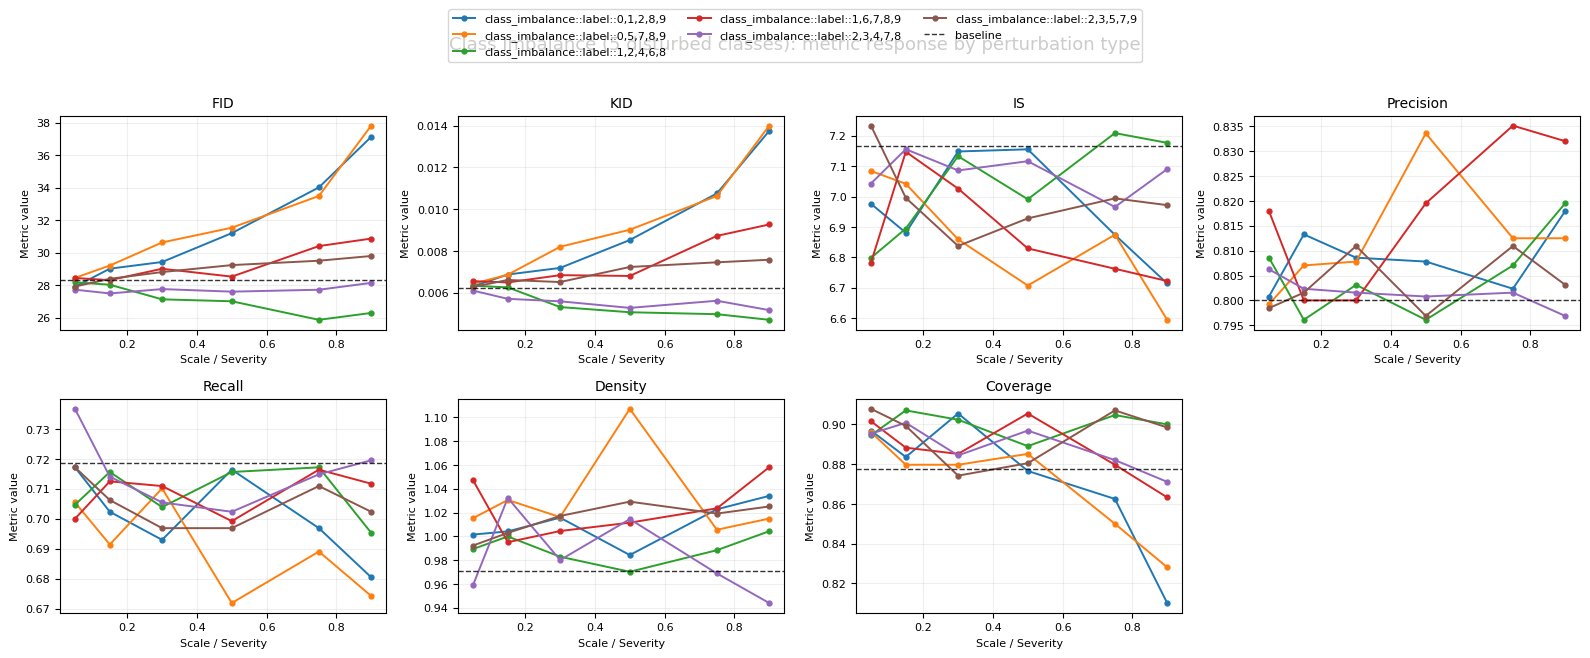

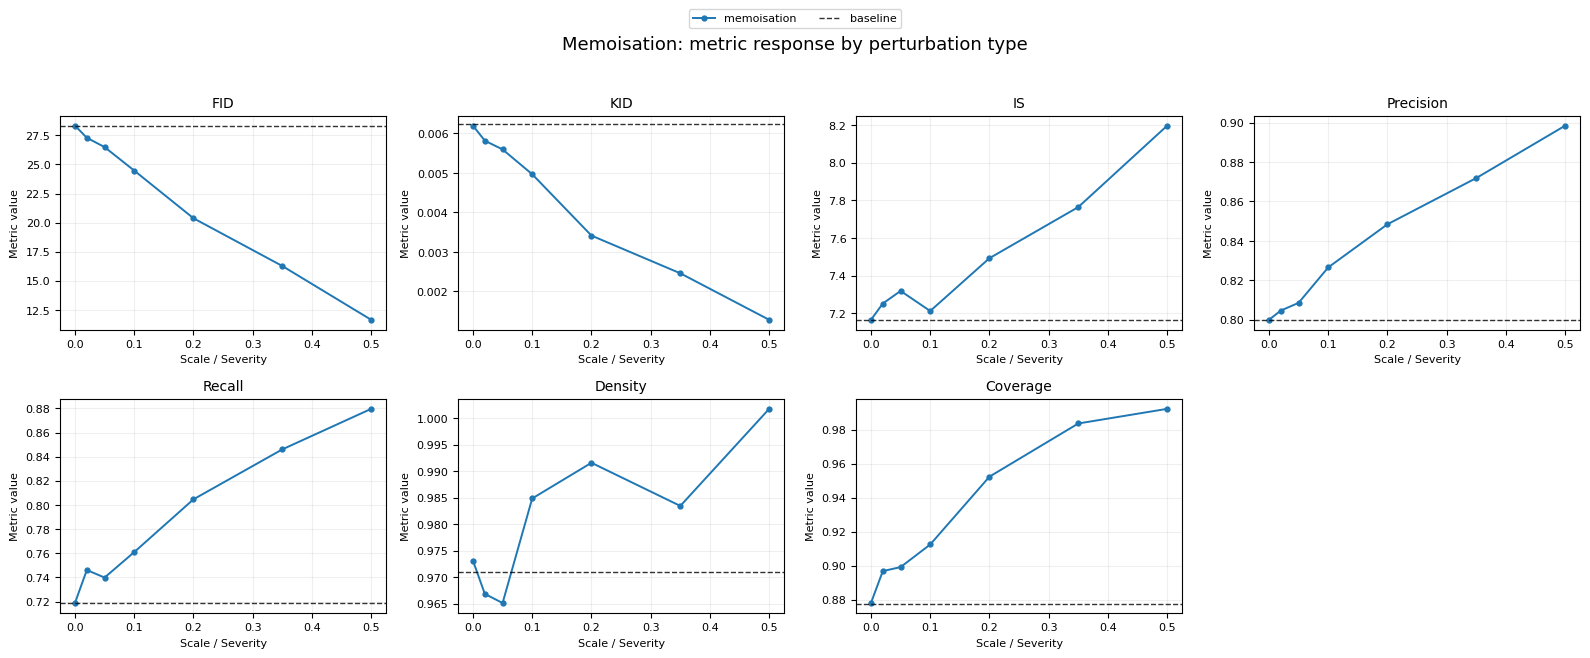

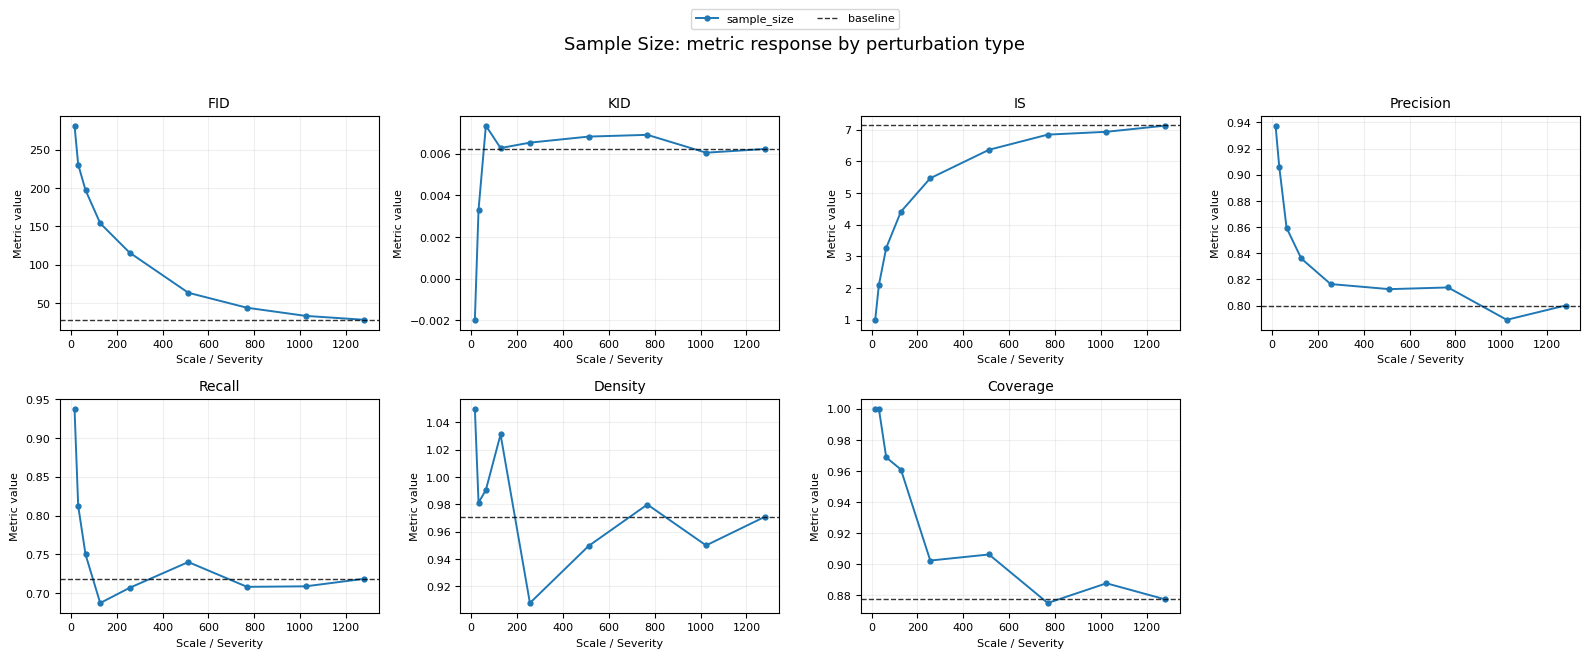

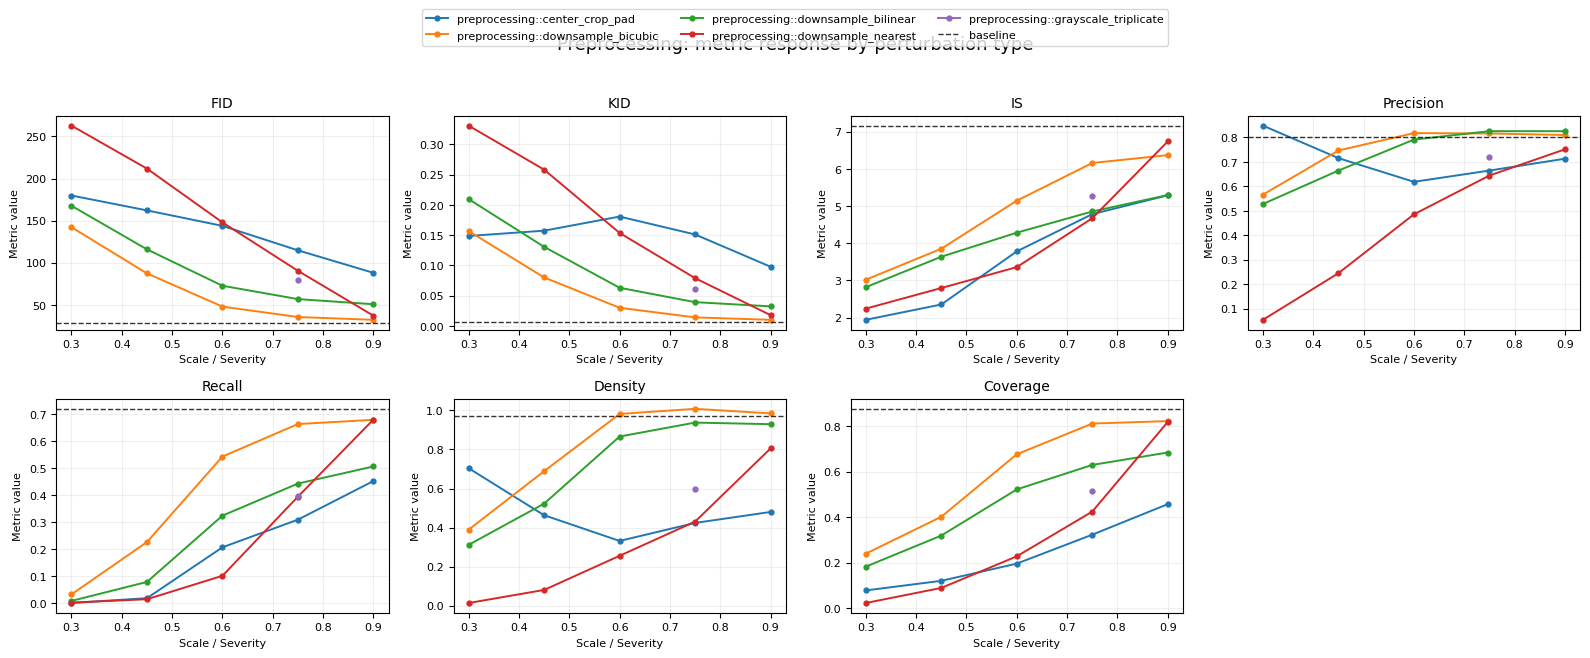

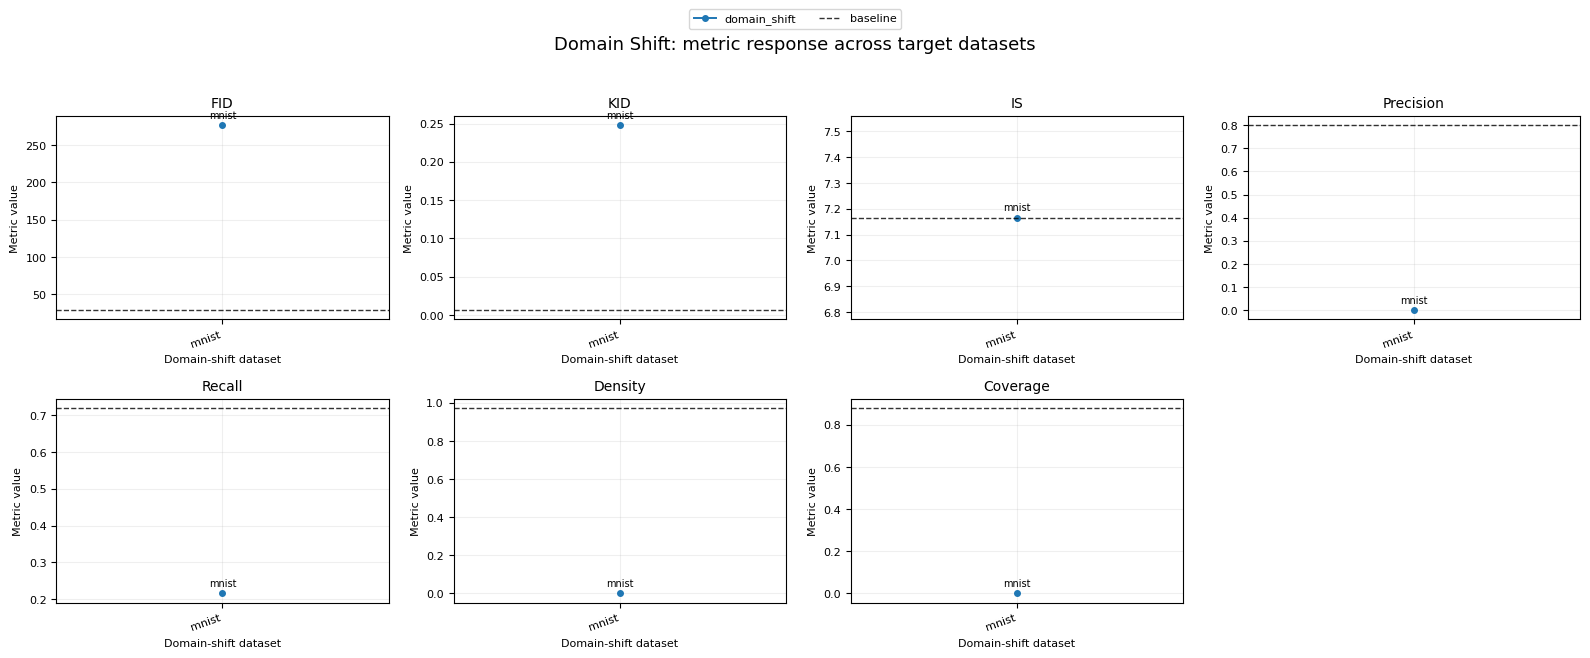

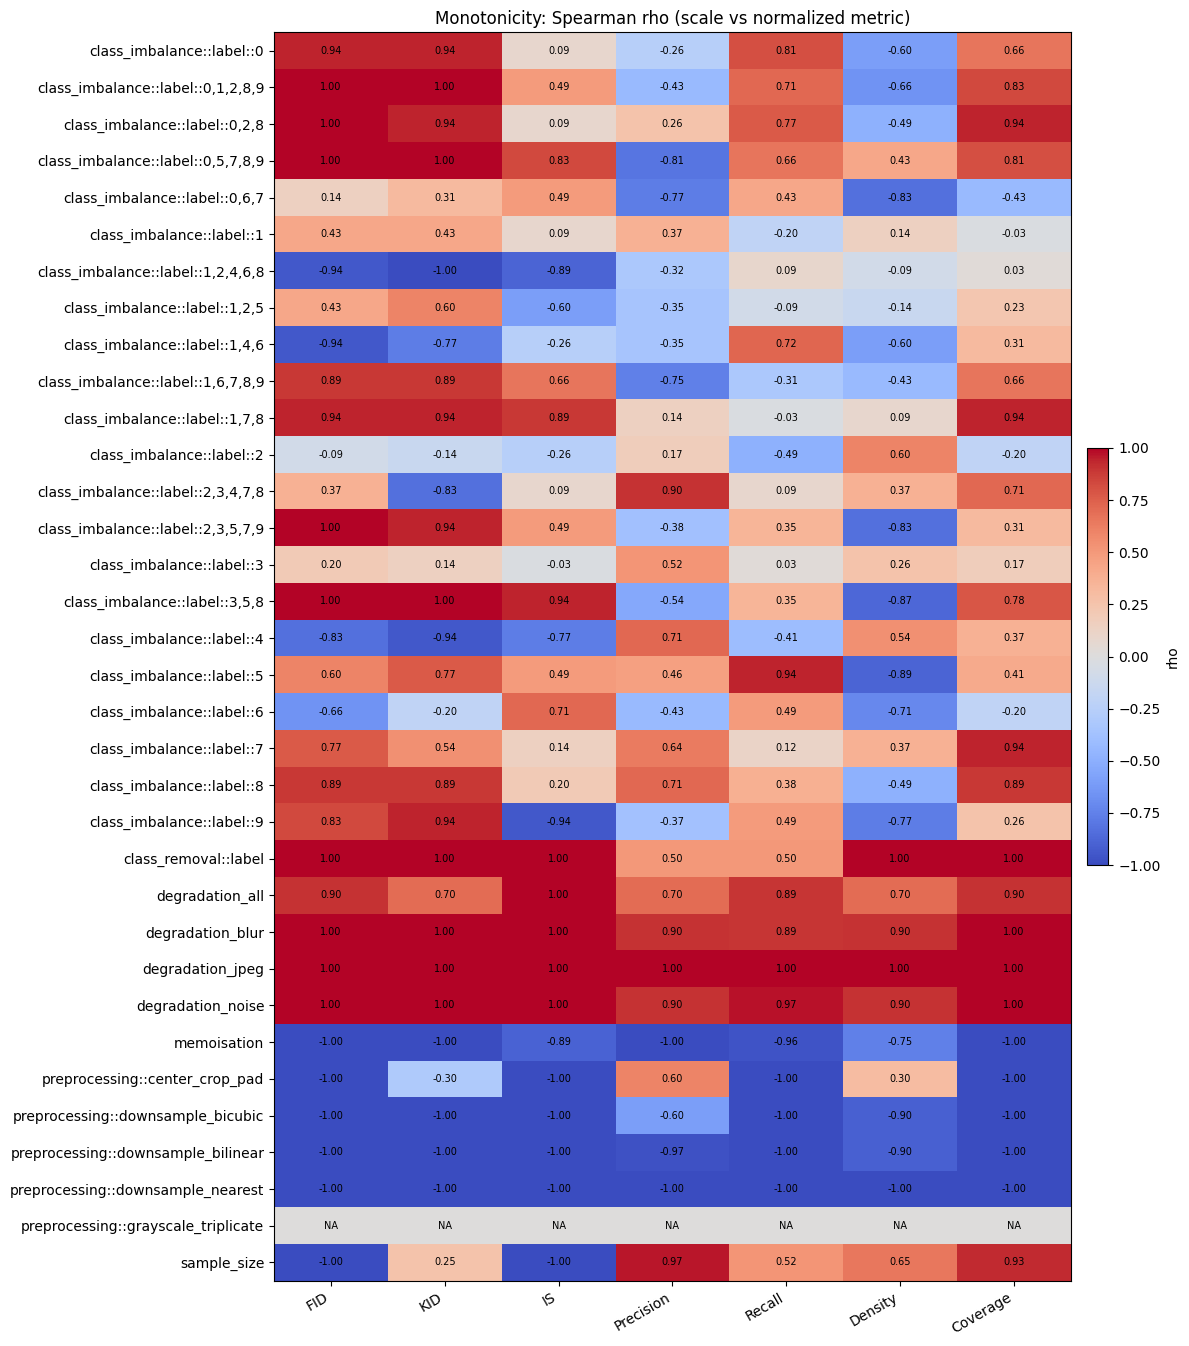

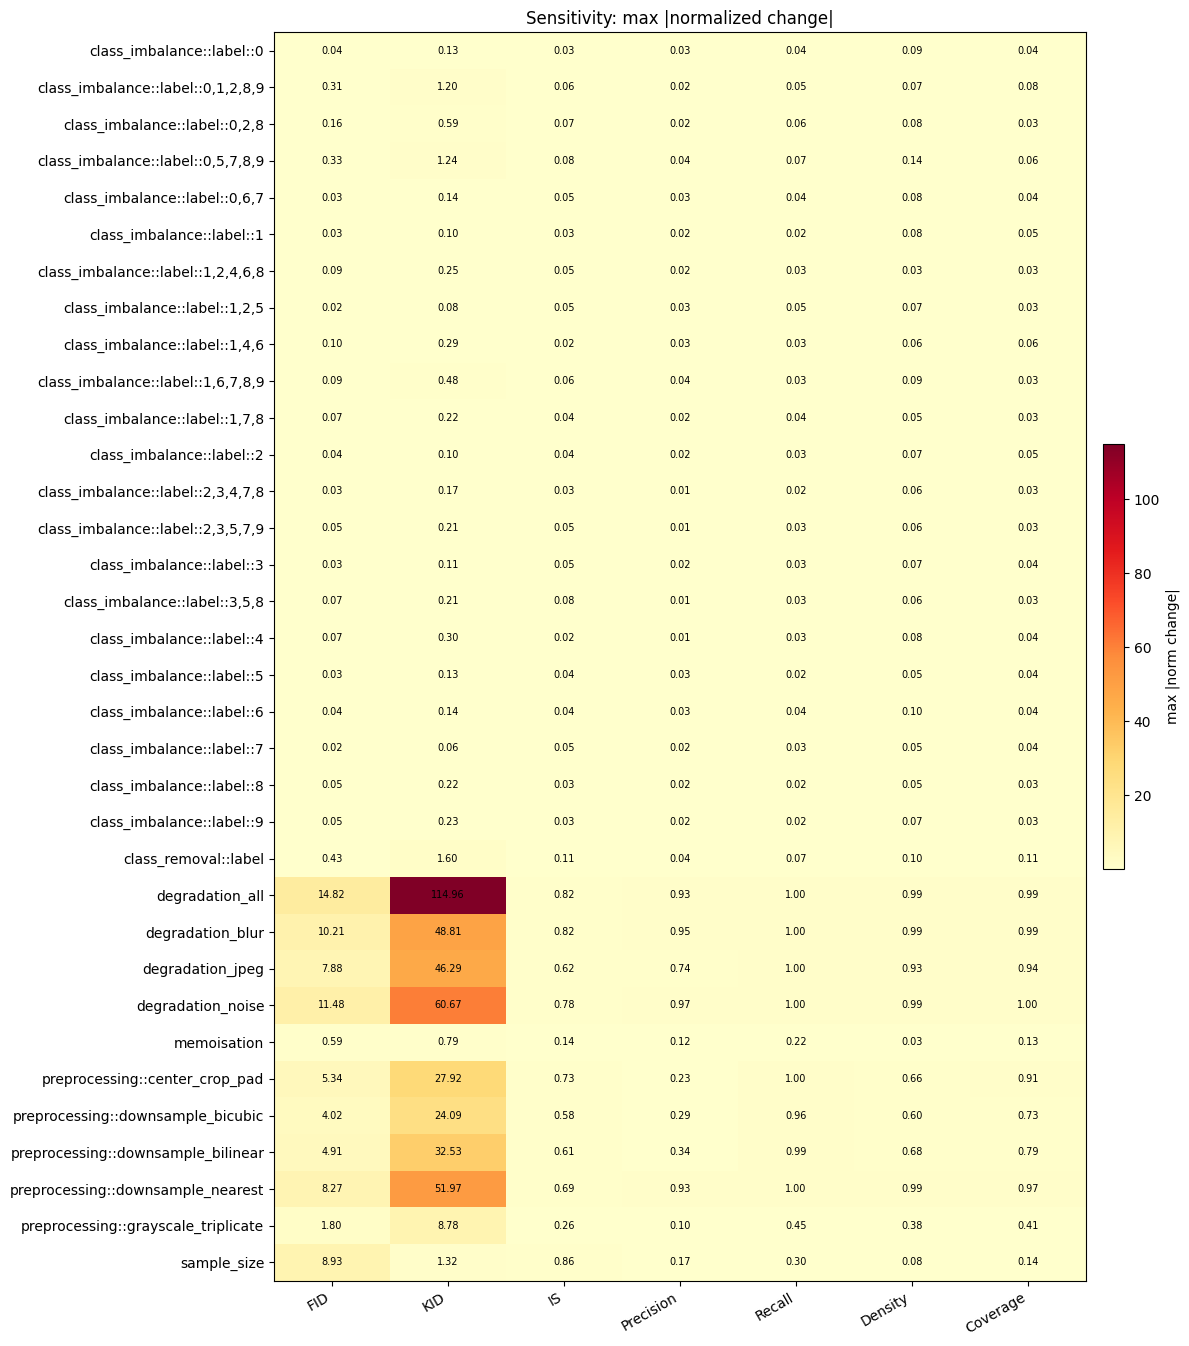

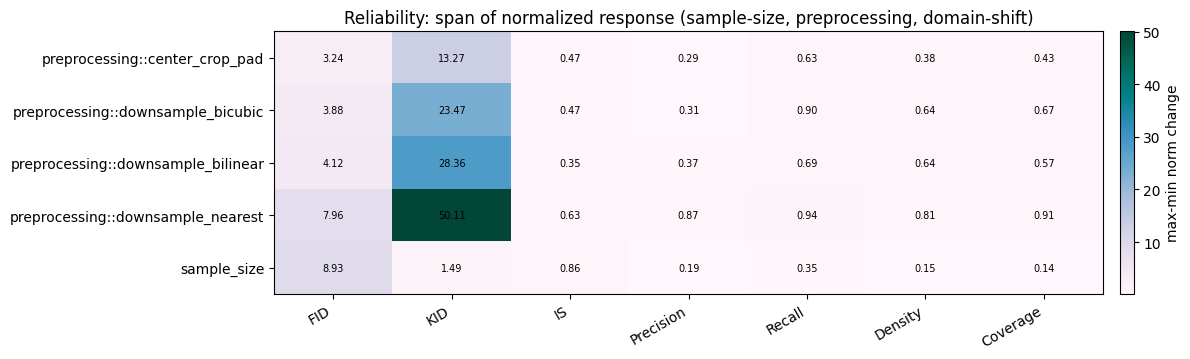

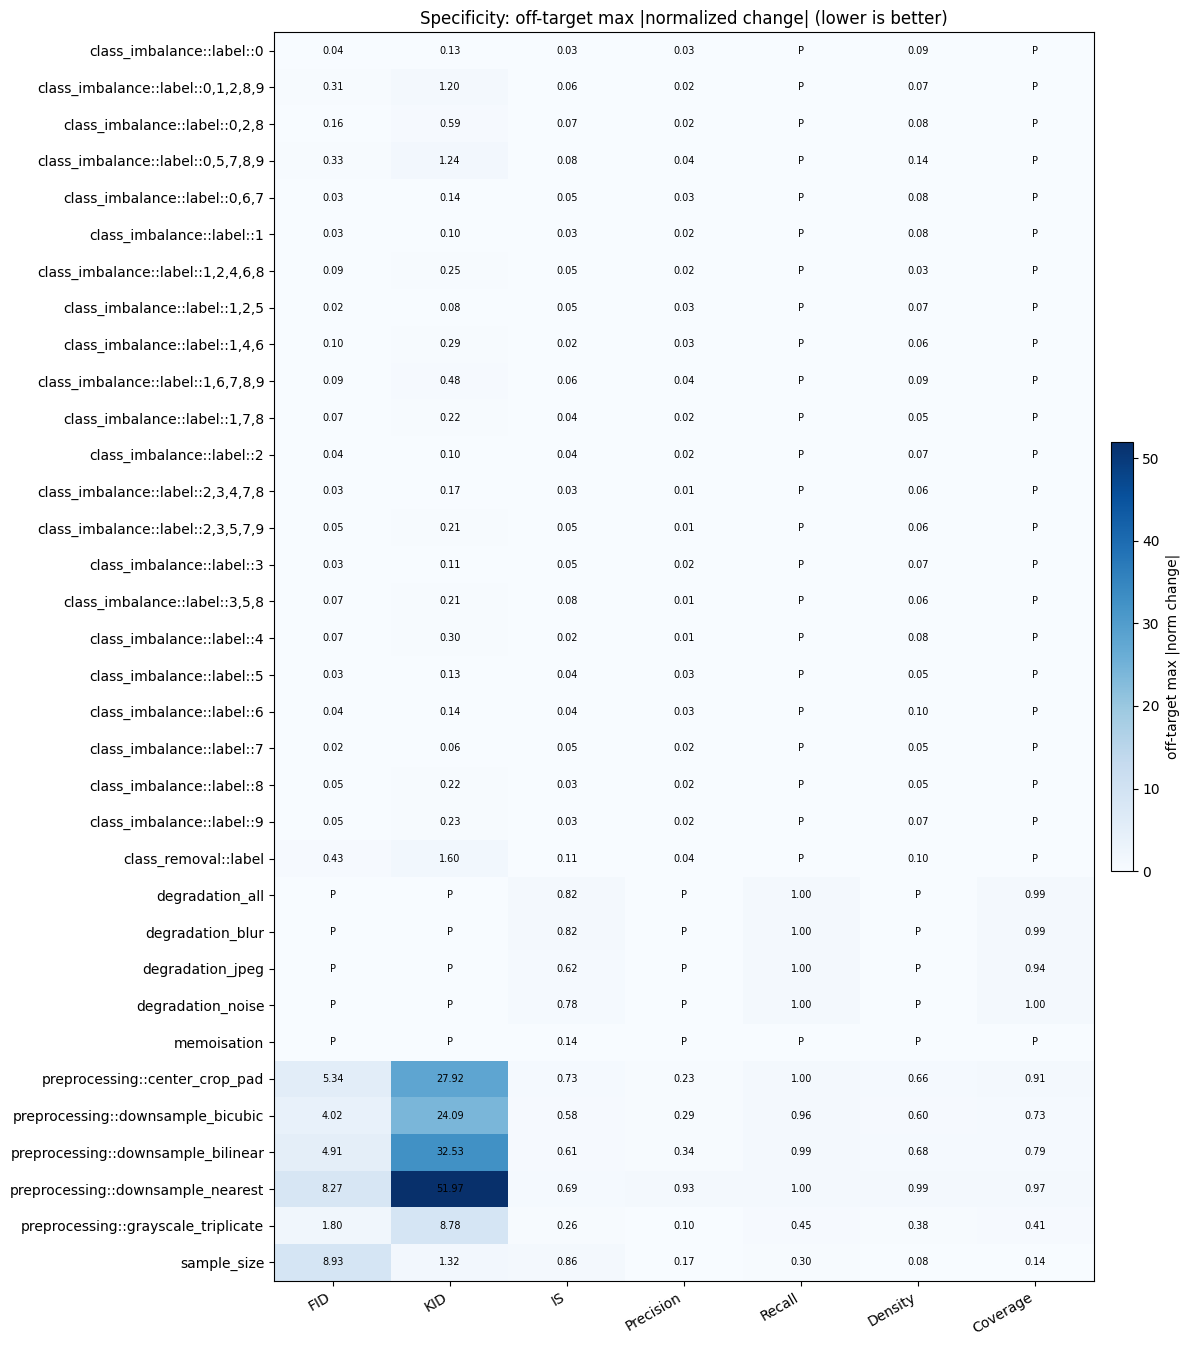

Perturbation groups included in curve analysis:
['class_imbalance::label::0', 'class_imbalance::label::0,1,2,8,9', 'class_imbalance::label::0,2,8', 'class_imbalance::label::0,5,7,8,9', 'class_imbalance::label::0,6,7', 'class_imbalance::label::1', 'class_imbalance::label::1,2,4,6,8', 'class_imbalance::label::1,2,5', 'class_imbalance::label::1,4,6', 'class_imbalance::label::1,6,7,8,9', 'class_imbalance::label::1,7,8', 'class_imbalance::label::2', 'class_imbalance::label::2,3,4,7,8', 'class_imbalance::label::2,3,5,7,9', 'class_imbalance::label::3', 'class_imbalance::label::3,5,8', 'class_imbalance::label::4', 'class_imbalance::label::5', 'class_imbalance::label::6', 'class_imbalance::label::7', 'class_imbalance::label::8', 'class_imbalance::label::9', 'class_removal::label', 'degradation_all', 'degradation_blur', 'degradation_jpeg', 'degradation_noise', 'memoisation', 'preprocessing::center_crop_pad', 'preprocessing::downsample_bicubic', 'preprocessing::downsample_bilinear', 'preprocessin

,specificity_kind,is_na,count
0,off_target,False,170
1,primary_metric,False,68


Monotonicity (head):


,perturbation_group,metric,rho_spearman,p_value,abs_rho
6,class_imbalance::label::0,coverage,0.657143,0.156175,0.657143
5,class_imbalance::label::0,density,-0.600000,0.208000,0.600000
0,class_imbalance::label::0,fid,0.942857,0.004805,0.942857
2,class_imbalance::label::0,is_mean,0.085714,0.871743,0.085714
1,class_imbalance::label::0,kid_mean,0.942857,0.004805,0.942857
3,class_imbalance::label::0,precision,-0.257143,0.622787,0.257143
4,class_imbalance::label::0,recall,0.811679,0.049858,0.811679
13,"class_imbalance::label::0,1,2,8,9",coverage,0.828571,0.041563,0.828571
12,"class_imbalance::label::0,1,2,8,9",density,-0.657143,0.156175,0.657143
7,"class_imbalance::label::0,1,2,8,9",fid,1.000000,0.000000,1.000000


Sensitivity (head):


...

Reliability (head):


,perturbation_group,metric,n_points,mean_norm,std_norm,cv_norm,span_norm
13,preprocessing::center_crop_pad,coverage,5,0.731968,0.158546,0.216602,0.432769
12,preprocessing::center_crop_pad,density,5,0.504892,0.126501,0.250551,0.383006
7,preprocessing::center_crop_pad,fid,5,3.858679,1.159795,0.300568,3.238377
9,preprocessing::center_crop_pad,is_mean,5,0.493619,0.183109,0.370953,0.467827
8,preprocessing::center_crop_pad,kid_mean,5,22.550230,4.344315,0.192651,13.268146
10,preprocessing::center_crop_pad,precision,5,0.109766,0.096094,0.875448,0.287109
11,preprocessing::center_crop_pad,recall,5,0.726087,0.239532,0.329895,0.628261
20,preprocessing::downsample_bicubic,coverage,5,0.326269,0.264595,0.810972,0.665183
19,preprocessing::downsample_bicubic,density,5,0.165465,0.248140,1.499655,0.636466
14,preprocessing::downsample_bicubic,fid,5,1.436843,1.463530,1.018573,3.878286


Specificity (head):


,perturbation_group,metric,off_target_max_abs_norm,off_target_mean_abs_norm,specificity_kind
6,class_imbalance::label::0,coverage,0.000000,0.000000,primary_metric
5,class_imbalance::label::0,density,0.093981,0.053589,off_target
0,class_imbalance::label::0,fid,0.042882,0.025776,off_target
2,class_imbalance::label::0,is_mean,0.031228,0.018384,off_target
1,class_imbalance::label::0,kid_mean,0.127174,0.068208,off_target
3,class_imbalance::label::0,precision,0.031250,0.016927,off_target
4,class_imbalance::label::0,recall,0.000000,0.000000,primary_metric
13,"class_imbalance::label::0,1,2,8,9",coverage,0.000000,0.000000,primary_metric
12,"class_imbalance::label::0,1,2,8,9",density,0.065014,0.040715,off_target
7,"class_imbalance::label::0,1,2,8,9",fid,0.309680,0.114731,off_target


,batch_label,model,dataset,rwfas_score,rwfas_ci_low,rwfas_ci_high,score_fid,score_kid_mean,score_is_mean,score_precision,...,norm_recall,norm_density,norm_coverage,weight_fid,weight_kid_mean,weight_is_mean,weight_precision,weight_recall,weight_density,weight_coverage
0,seed_01_ddpm_cifar10_perturbation_tests,ddpm,cifar10,0.468599,0.307688,0.629509,0.390803,0.388683,0.43717,0.475532,...,0.144092,0.075407,0.109406,0.0,0.0,0.002678,0.485507,0.0,0.508479,0.003337


In [21]:
analysis_input = prepare_full_analysis_input(df_delta)
tables = run_full_perturbation_analysis(analysis_input)

rwfas = RWFAS().fit(
    df_delta,
    tables['monotonicity'],
    tables['sensitivity'],
    tables['specificity'],
    tables['robustness'],
    batch_label=report_path.stem,
)

single_batch_scores = rwfas.score_all(df_delta)
single_batch_scores

In [22]:
components_df = pd.DataFrame(rwfas.components_).T
components_df

,sensitivity,specificity,monotonicity,reliability,raw_weight,redundancy_penalty,final_weight
fid,0.177878,0.794729,0.980000,0.000000,0.000000,0.140906,0.000000
kid_mean,1.000000,0.000000,0.940000,0.500000,0.000000,0.103584,0.000000
is_mean,0.000279,0.865131,0.495652,0.500000,0.000060,0.136847,0.002678
precision,0.011880,1.000000,0.900000,1.000000,0.010692,0.138587,0.485507
recall,0.000000,0.799262,0.410106,0.999591,0.000000,0.124522,0.000000
density,0.018403,0.978785,0.850000,0.985506,0.015089,0.102852,0.508479
coverage,0.000229,0.816872,0.527236,0.998764,0.000099,0.103226,0.003337


### Weight component breakdown (single batch)

Each bar group shows the four trustworthiness components (S, Sp, M, R)
for one metric, and the resulting normalised weight.
This makes it easy to see *why* each metric received its weight.

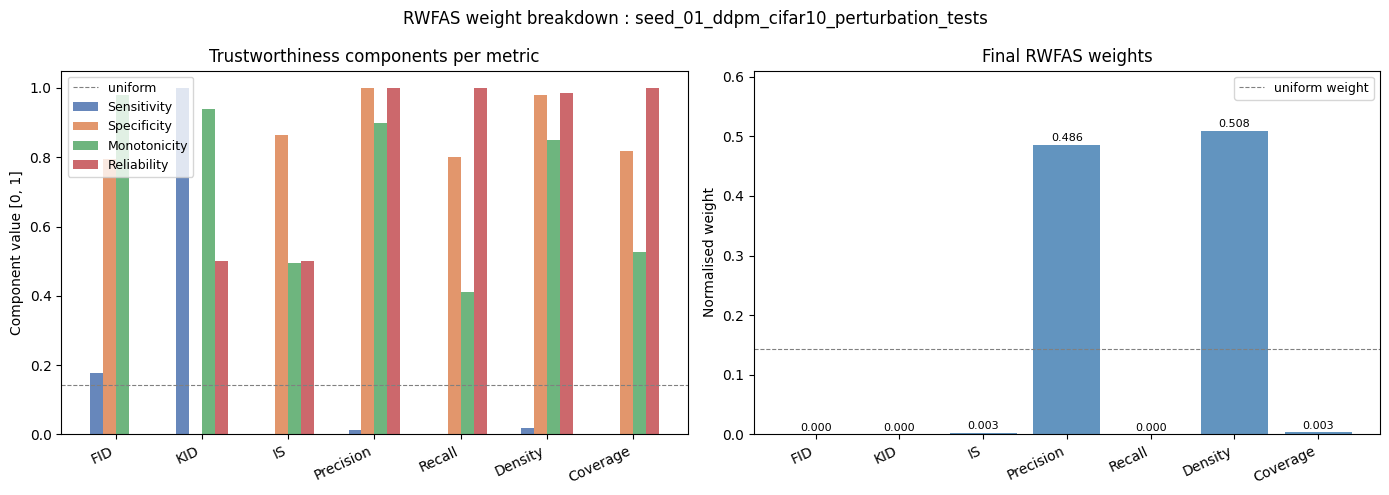

Saved: outputs/task3_weight_breakdown.png


In [24]:
if rwfas.components_:
    comp_df = pd.DataFrame(rwfas.components_).T[
        ['sensitivity','specificity','monotonicity','reliability','final_weight']
    ].copy()
    comp_df.index = [METRIC_LABELS.get(m, m) for m in comp_df.index]

    n_metrics   = len(comp_df)
    n_comp      = 4   # S, Sp, M, R (not final_weight)
    comp_keys   = ['sensitivity','specificity','monotonicity','reliability']
    comp_colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
    bar_width   = 0.15
    x           = np.arange(n_metrics)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: grouped bars for S, Sp, M, R
    for i, (key, color) in enumerate(zip(comp_keys, comp_colors)):
        vals = comp_df[key].to_numpy(dtype=float)
        ax1.bar(x + i * bar_width, vals, width=bar_width, label=key.capitalize(),
                color=color, alpha=0.85)
    ax1.set_xticks(x + bar_width * 1.5)
    ax1.set_xticklabels(comp_df.index, rotation=25, ha='right')
    ax1.set_ylabel('Component value [0, 1]')
    ax1.set_ylim(0, 1.05)
    ax1.axhline(1/n_metrics, linestyle='--', color='grey', linewidth=0.8, label='uniform')
    ax1.set_title('Trustworthiness components per metric')
    ax1.legend(fontsize=9)

    # Right: final normalised weights
    weights = comp_df['final_weight'].to_numpy(dtype=float)
    bars = ax2.bar(x, weights, color='steelblue', alpha=0.85)
    ax2.axhline(1/n_metrics, linestyle='--', color='grey', linewidth=0.8, label='uniform weight')
    ax2.set_xticks(x)
    ax2.set_xticklabels(comp_df.index, rotation=25, ha='right')
    ax2.set_ylabel('Normalised weight')
    ax2.set_ylim(0, max(weights.max() * 1.2, 1/n_metrics * 1.5) if weights.size else 0.3)
    ax2.set_title('Final RWFAS weights')
    ax2.legend(fontsize=9)
    for bar, val in zip(bars, weights):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    fig.suptitle(f'RWFAS weight breakdown : {report_path.stem}', fontsize=12)
    plt.tight_layout()
    plt.savefig(repo_root / 'outputs' / 'task3_weight_breakdown.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/task3_weight_breakdown.png')

### Sensitivity vs specificity table (single batch)

Rows = perturbation groups. Columns = metrics.
- **Sensitivity table**: how much each metric responds when it is the target.
- **Specificity table**: how much each metric drifts when it is NOT the target
  (lower is bette )

In [25]:
if not tables['sensitivity'].empty:
    sens_piv = (
        tables['sensitivity']
        .pivot(index='perturbation_group', columns='metric', values='mean_abs_norm_change')
        .reindex(columns=METRICS)
        .rename(columns=METRIC_LABELS)
    )
    print('Sensitivity (mean |normalised change|) — higher = metric responds more strongly:')
    display(sens_piv.round(4))

if not tables['specificity'].empty:
    spec_piv = (
        tables['specificity']
        .pivot(index='perturbation_group', columns='metric', values='off_target_mean_abs_norm')
        .reindex(columns=METRICS)
        .rename(columns=METRIC_LABELS)
    )
    print('\nSpecificity (mean |off-target change|) — lower = metric stays stable;')
    print('P = primary/target cell (not scored for specificity):')
    display(spec_piv.round(4))

Sensitivity (mean |normalised change|) — higher = metric responds more strongly:


metric,FID,KID,IS,Precision,Recall,Density,Coverage
perturbation_group,,,,,,,
class_imbalance::label::0,0.0258,0.0682,0.0184,0.0169,0.0263,0.0536,0.0236
"class_imbalance::label::0,1,2,8,9",0.1147,0.4250,0.0289,0.0106,0.0246,0.0407,0.0260
"class_imbalance::label::0,2,8",0.0649,0.2124,0.0503,0.0083,0.0382,0.0413,0.0165
"class_imbalance::label::0,5,7,8,9",0.1240,0.4716,0.0426,0.0155,0.0395,0.0625,0.0205
"class_imbalance::label::0,6,7",0.0078,0.0458,0.0311,0.0146,0.0210,0.0439,0.0230
class_imbalance::label::1,0.0117,0.0374,0.0202,0.0112,0.0118,0.0390,0.0358
"class_imbalance::label::1,2,4,6,8",0.0441,0.1341,0.0209,0.0096,0.0139,0.0191,0.0254
"class_imbalance::label::1,2,5",0.0107,0.0335,0.0261,0.0117,0.0212,0.0483,0.0206
"class_imbalance::label::1,4,6",0.0644,0.1866,0.0121,0.0096,0.0185,0.0308,0.0413



Specificity (mean |off-target change|) — lower = metric stays stable;
P = primary/target cell (not scored for specificity):


metric,FID,KID,IS,Precision,Recall,Density,Coverage
perturbation_group,,,,,,,
class_imbalance::label::0,0.0258,0.0682,0.0184,0.0169,0.0000,0.0536,0.0000
"class_imbalance::label::0,1,2,8,9",0.1147,0.4250,0.0289,0.0106,0.0000,0.0407,0.0000
"class_imbalance::label::0,2,8",0.0649,0.2124,0.0503,0.0083,0.0000,0.0413,0.0000
"class_imbalance::label::0,5,7,8,9",0.1240,0.4716,0.0426,0.0155,0.0000,0.0625,0.0000
"class_imbalance::label::0,6,7",0.0078,0.0458,0.0311,0.0146,0.0000,0.0439,0.0000
class_imbalance::label::1,0.0117,0.0374,0.0202,0.0112,0.0000,0.0390,0.0000
"class_imbalance::label::1,2,4,6,8",0.0441,0.1341,0.0209,0.0096,0.0000,0.0191,0.0000
"class_imbalance::label::1,2,5",0.0107,0.0335,0.0261,0.0117,0.0000,0.0483,0.0000
"class_imbalance::label::1,4,6",0.0644,0.1866,0.0121,0.0096,0.0000,0.0308,0.0000
